In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
ROOT=Path.cwd().parent
DATA_PROCESSED = ROOT / 'data' / 'processed'

# Load cleaned data
df = pd.read_csv(DATA_PROCESSED / 'ads_cleaned.csv')
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Platforms: {df['channel_used'].unique()}")

Loaded: 300,000 rows x 25 cols
Platforms: ['Instagram' 'Facebook' 'Pinterest' 'Twitter']


In [7]:
#ROAS= Revenue/Ad Spend
platform_budget=df.groupby('channel_used').agg(
    total_spend=('acquisition_cost','sum'),
    total_revenue=('estimated_revenue','sum'),
    avg_roi=('roi','mean'),
    avg_ctr=('ctr','mean'),
    avg_conv_rate=('conversion_rate','mean'),
    campaigns=('campaign_id','count')
).reset_index()

platform_budget['roas']=(platform_budget['total_revenue']/platform_budget['total_spend']).round(3)
platform_budget['profit']=(platform_budget['total_revenue']-platform_budget['total_spend']).round(2)
platform_budget['current_pct']=(platform_budget['total_spend']/platform_budget['total_spend'].sum()*100).round(1)


#Efficiency score=weighted combination of ROAS, CTR, Conversion rate
def minmax(series):
    return (series - series.min()) / (series.max() - series.min())

platform_budget['efficiency_score'] = (
    minmax(platform_budget['roas']) +
    minmax(platform_budget['avg_ctr']) +
    minmax(platform_budget['avg_conv_rate'])
).div(3).round(4)

#Recommended budget allocation based on efficiency
platform_budget['recommended_pct']=(
    platform_budget['efficiency_score']/platform_budget['efficiency_score'].sum()*100
).round(1)

platform_budget['budget_change']=(
    platform_budget['recommended_pct']-platform_budget['current_pct']
).round(1)

print(platform_budget[['channel_used','current_pct','recommended_pct','budget_change','roas']].to_string(index=False))

# Save budget comparison for Tableau
budget_export = platform_budget[['channel_used', 'current_pct', 'recommended_pct']].copy()
budget_export_melted = budget_export.melt(
    id_vars='channel_used',
    value_vars=['current_pct', 'recommended_pct'],
    var_name='allocation_type',
    value_name='percentage'
)
budget_export_melted['allocation_type'] = budget_export_melted['allocation_type'].str.replace('_pct','').str.replace('_',' ').str.title()
budget_export_melted.to_csv('../data/processed/budget_allocation.csv', index=False)
print(budget_export_melted)

channel_used  current_pct  recommended_pct  budget_change  roas
    Facebook         25.0             28.4            3.4 4.989
   Instagram         24.9             26.1            1.2 5.010
   Pinterest         25.1              6.1          -19.0 1.717
     Twitter         24.9             39.4           14.5 4.997
  channel_used allocation_type  percentage
0     Facebook         Current        25.0
1    Instagram         Current        24.9
2    Pinterest         Current        25.1
3      Twitter         Current        24.9
4     Facebook     Recommended        28.4
5    Instagram     Recommended        26.1
6    Pinterest     Recommended         6.1
7      Twitter     Recommended        39.4


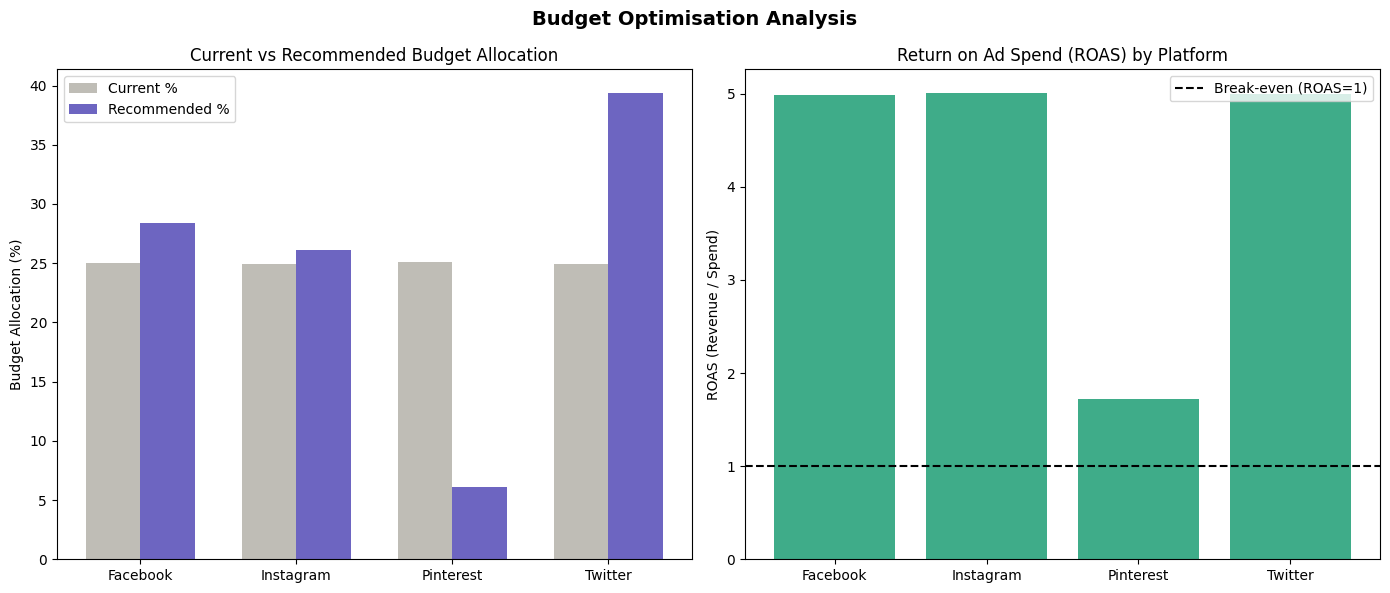

In [4]:
fig,axes=plt.subplots(1,2,figsize=(14,6))

platforms_list=platform_budget['channel_used']
x=range(len(platforms_list))
width=0.35

axes[0].bar([i-width/2 for i in x], platform_budget['current_pct'],width=width,label='Current %', color='#B4B2A9',alpha=0.85)
axes[0].bar([i+width/2 for i in x],platform_budget['recommended_pct'],width=width,label='Recommended %',color='#534AB7',alpha=0.85)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(platforms_list)
axes[0].set_ylabel('Budget Allocation (%)')
axes[0].set_title('Current vs Recommended Budget Allocation')
axes[0].legend()


#ROAS Comparison
colors_roas = ['#1D9E75' if r > 1 else '#D85A30' for r in platform_budget['roas']]
axes[1].bar(platform_budget['channel_used'], platform_budget['roas'],
            color=colors_roas, alpha=0.85)
axes[1].axhline(y=1, color='black', linestyle='--', linewidth=1.5, label='Break-even (ROAS=1)')
axes[1].set_ylabel('ROAS (Revenue / Spend)')
axes[1].set_title('Return on Ad Spend (ROAS) by Platform')
axes[1].legend()

plt.suptitle('Budget Optimisation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/budget_optimisation.png',dpi=150,bbox_inches="tight")
plt.show()


In [8]:
avg_ctr  = df['ctr'].mean()
avg_roas = platform_budget['roas'].mean()
total_campaigns = df['campaign_id'].nunique()
best_platform = platform_budget.loc[platform_budget['roas'].idxmax(), 'channel_used']

print(f"Total Campaigns:  {total_campaigns:,}")
print(f"Avg CTR:          {avg_ctr:.4f}%")
print(f"Avg ROAS:         {avg_roas:.3f}")
print(f"Best Platform:    {best_platform}")

Total Campaigns:  255,092
Avg CTR:          31.4156%
Avg ROAS:         4.178
Best Platform:    Instagram
